# Multivariate Time Series

Four Indian market series, daily 2016-08-25 → 2026-08-24: **NIFTY 50**, **NIFTY Bank**, **NIFTY IT** and **India VIX**. Saved at `../data/nifty_indices.csv`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.api import VAR
from statsmodels.tsa.statespace.varmax import VARMAX
from statsmodels.tsa.stattools import adfuller, acf

import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

lvl = pd.read_csv("../data/nifty_indices.csv", parse_dates=["ds"]).set_index("ds")
print(lvl.shape, lvl.index.min().date(), "->", lvl.index.max().date())
lvl.tail(3).round(2)

(2447, 4) 2016-08-25 -> 2026-08-24


,NIFTY50,BANK,IT,VIX
ds,,,,
2026-08-20,24231.85,57495.90,30673.05,10.76
2026-08-21,24252.00,57761.95,30532.25,11.20
2026-08-24,24219.05,57525.95,30596.90,11.53


## 1. VAR (Vector AutoRegression)

**The idea.** A univariate AR explains a series by its own past. A VAR lets **every** series depend on the past of **every** series — one equation per variable, estimated jointly. Nothing is designated "dependent"; all variables are endogenous.

**VAR(p) for $K$ variables**, with $\mathbf{y}_t = (y_{1t},\dots,y_{Kt})'$:

$$\mathbf{y}_t = \mathbf{c} + \Phi_1 \mathbf{y}_{t-1} + \cdots + \Phi_p \mathbf{y}_{t-p} + \boldsymbol{\varepsilon}_t, \qquad \boldsymbol{\varepsilon}_t \sim (\mathbf{0}, \Sigma)$$

Each $\Phi_i$ is $K \times K$. Written out for $K=2$, $p=1$:

$$\begin{aligned}
y_{1t} &= c_1 + \phi_{11} y_{1,t-1} + \phi_{12} y_{2,t-1} + \varepsilon_{1t}\\
y_{2t} &= c_2 + \phi_{21} y_{1,t-1} + \phi_{22} y_{2,t-1} + \varepsilon_{2t}
\end{aligned}$$

The **off-diagonal** terms $\phi_{12}, \phi_{21}$ are the whole point — they carry the cross-series dynamics.

**Stationarity is required**, exactly as for ARMA. Levels here have unit roots, so the VAR is built on **log differences** (daily % changes).

**Cost.** A VAR(p) has $K^2p + K$ parameters — for $K=4, p=7$ that is **116**. Parameters grow with the *square* of the number of variables, so keep $K$ small and $p$ short.

ADF p-values
series            level     log-diff
NIFTY50          0.8764    2.466e-25
BANK              0.842    6.305e-25
IT               0.6224    8.175e-17
VIX            0.001159    8.329e-23

lag-1 autocorrelation of the differenced series (over-differencing check)
  NIFTY50    -0.047
  BANK       +0.010
  IT         -0.011
  VIX        -0.034


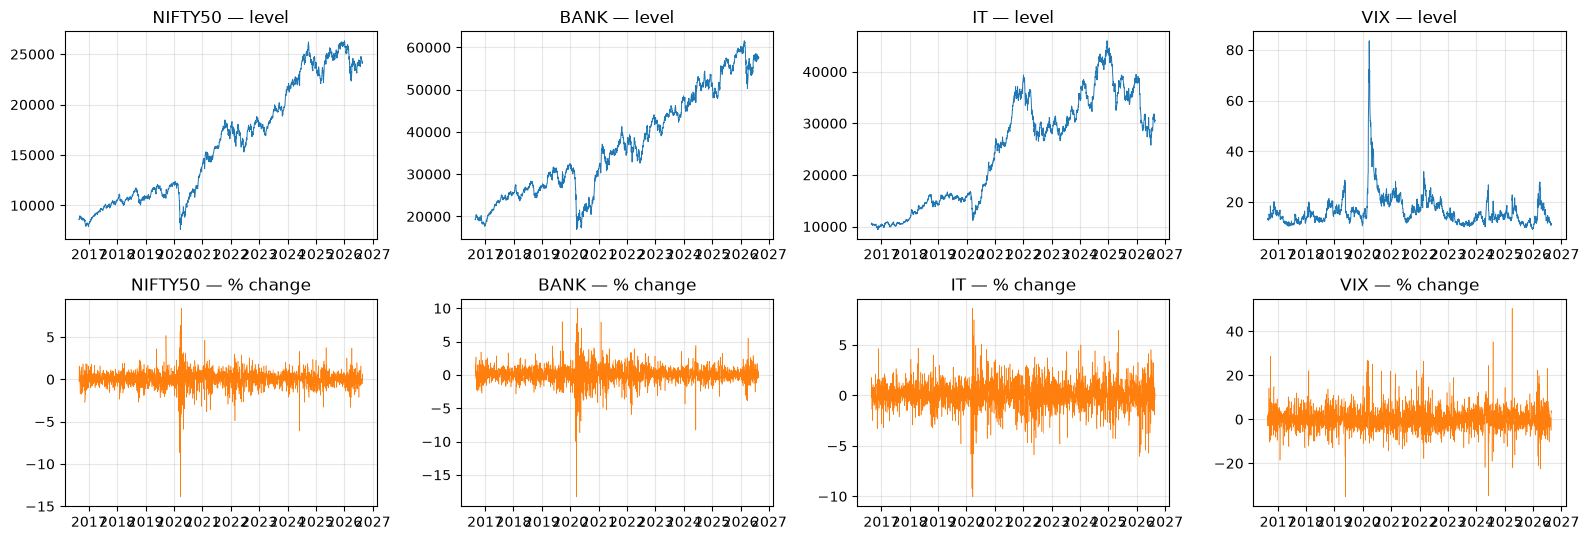

In [2]:
ret = 100 * np.log(lvl).diff().dropna()

print("ADF p-values")
print(f"{'series':10s} {'level':>12s} {'log-diff':>12s}")
for c in lvl.columns:
    print(f"{c:10s} {adfuller(lvl[c], autolag='AIC')[1]:12.4g} {adfuller(ret[c], autolag='AIC')[1]:12.4g}")

print("\nlag-1 autocorrelation of the differenced series (over-differencing check)")
for c in ret.columns:
    print(f"  {c:10s} {acf(ret[c], nlags=1)[1]:+.3f}")

fig, axes = plt.subplots(2, 4, figsize=(16, 5.5))
for j, c in enumerate(lvl.columns):
    axes[0, j].plot(lvl.index, lvl[c], lw=0.7); axes[0, j].set_title(f"{c} — level")
    axes[1, j].plot(ret.index, ret[c], lw=0.4, color="tab:orange"); axes[1, j].set_title(f"{c} — % change")
plt.tight_layout(); plt.show()

The three price indices have unit roots (p = 0.88, 0.84, 0.62). **India VIX is already stationary in levels** (p = 0.0012) — a volatility index mean-reverts. Differencing it is therefore a choice made for unit consistency, not a necessity. It is harmless here: the lag-1 autocorrelation of $\Delta\log$VIX is −0.034, nowhere near the ≈ −0.5 that would signal over-differencing.

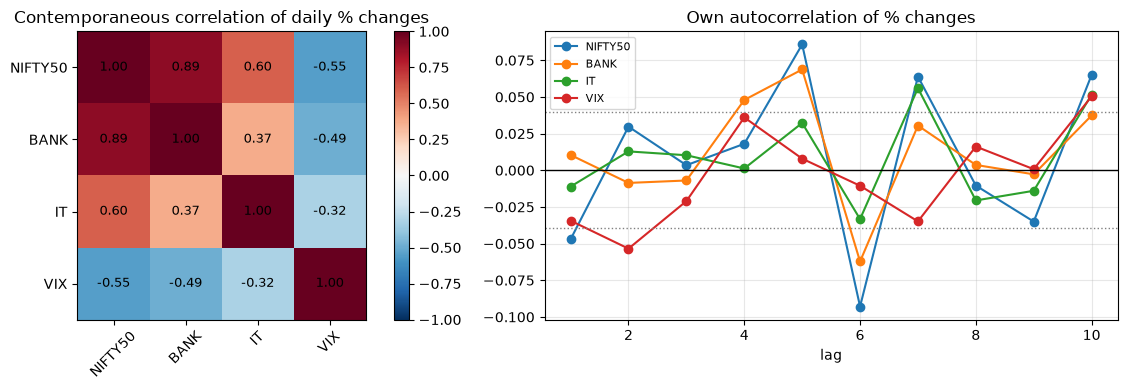

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

C = ret.corr()
im = axes[0].imshow(C, cmap="RdBu_r", vmin=-1, vmax=1)
axes[0].set_xticks(range(4), C.columns, rotation=45)
axes[0].set_yticks(range(4), C.index)
for i in range(4):
    for j in range(4):
        axes[0].text(j, i, f"{C.iloc[i, j]:.2f}", ha="center", va="center", fontsize=9)
axes[0].set_title("Contemporaneous correlation of daily % changes")
axes[0].grid(False)
plt.colorbar(im, ax=axes[0], fraction=0.046)

band = 1.96 / np.sqrt(len(ret))
for c in ret.columns:
    axes[1].plot(range(1, 11), acf(ret[c], nlags=10)[1:11], marker="o", label=c)
axes[1].axhline(0, color="black", lw=1)
axes[1].axhline(band, color="grey", ls=":", lw=1)
axes[1].axhline(-band, color="grey", ls=":", lw=1)
axes[1].set_xlabel("lag"); axes[1].set_title("Own autocorrelation of % changes")
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

NIFTY 50 and NIFTY Bank move together **on the same day** (r = 0.89), and VIX moves against the index (r = −0.55 — the leverage effect). But the own-autocorrelations sit inside the significance band: individually, none of these series predicts itself. Whether they predict *each other* is the VAR's question.

### Choosing the lag order $p$

Fit across a range of $p$ and minimise an information criterion. AIC keeps more lags (better for forecasting), BIC fewer (consistent for the true order).

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0        2.040      2.049*       7.690      2.043*
1        2.034       2.082       7.648       2.052
2        2.028       2.113       7.596       2.059
3        2.033       2.157       7.637       2.078
4        2.038       2.200       7.672       2.097
5        2.034       2.235       7.648       2.107
6        2.018       2.257       7.526       2.105
7       2.016*       2.293      7.510*       2.117
8        2.023       2.338       7.559       2.137
9        2.027       2.379       7.588       2.155
10       2.026       2.417       7.587       2.169
11       2.031       2.461       7.624       2.187
12       2.037       2.505       7.670       2.207
13       2.046       2.551       7.736       2.230
14       2.046       2.589       7.735       2.243
15       2.054       2.635       7.796       2.265
-------------------------------

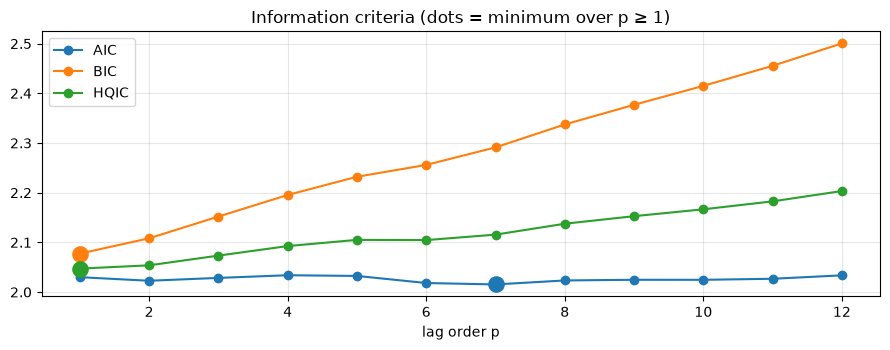


minimum over p ≥ 1: {'aic': 7, 'bic': 1, 'hqic': 1}


In [4]:
print(VAR(ret).select_order(15).summary())

crit = pd.DataFrame({k: [getattr(VAR(ret).fit(p), k) for p in range(1, 13)]
                     for k in ("aic", "bic", "hqic")}, index=range(1, 13))

fig, ax = plt.subplots(figsize=(9, 3.6))
for k in crit:
    ax.plot(crit.index, crit[k], marker="o", label=k.upper())
    ax.scatter([crit[k].idxmin()], [crit[k].min()], s=120, zorder=5)
ax.set_xlabel("lag order p"); ax.set_title("Information criteria (dots = minimum over p ≥ 1)")
ax.legend(); plt.tight_layout(); plt.show()

print("\nminimum over p ≥ 1:", {k: int(crit[k].idxmin()) for k in crit})

In the full `select_order` table **AIC picks 7 while BIC and HQIC pick 0** — no lags at all. That is the efficient-market result stated in model-selection terms: past daily returns carry almost no linear information about future ones.

The disagreement is expected. BIC's penalty grows with $\log T$ and each extra lag costs $K^2 = 16$ parameters, so BIC is far stricter. We use **p = 2** below: short enough to stay interpretable, long enough to show the machinery.

In [5]:
P = 2
var_res = VAR(ret).fit(P)

print(f"VAR({P}):  K = {ret.shape[1]}   parameters = {ret.shape[1]**2 * P + ret.shape[1]}"
      f"   stable = {var_res.is_stable()}")
print(f"AIC {var_res.aic:.4f}   BIC {var_res.bic:.4f}\n")

print("Φ₁ — coefficient on each variable's lag 1 (rows = equation, cols = regressor)")
print(pd.DataFrame(var_res.coefs[0], index=ret.columns,
                   columns=[f"{c}(t-1)" for c in ret.columns]).round(4).to_string())

VAR(2):  K = 4   parameters = 36   stable = True
AIC 2.0228   BIC 2.1082

Φ₁ — coefficient on each variable's lag 1 (rows = equation, cols = regressor)
         NIFTY50(t-1)  BANK(t-1)  IT(t-1)  VIX(t-1)
NIFTY50       -0.1635     0.0789   0.0082   -0.0064
BANK          -0.2580     0.1760   0.0098   -0.0036
IT            -0.1292     0.0256   0.0254   -0.0098
VIX            0.1695     0.1304  -0.1063   -0.0102


Reading $\Phi_1$: the row is the equation being explained, the column is the regressor. The diagonal is own-persistence, the off-diagonals are the cross-effects. Every entry is small — consistent with returns being close to unpredictable.

### Impulse response functions

An IRF traces what happens to the whole system when **one** variable receives a one-off shock. Because the residuals are contemporaneously correlated, shocks are **orthogonalised** (Cholesky), which imposes an ordering: the variable listed first can affect all others within the same day, the last affects none of them contemporaneously. **The ordering is an assumption, and the answers depend on it.**

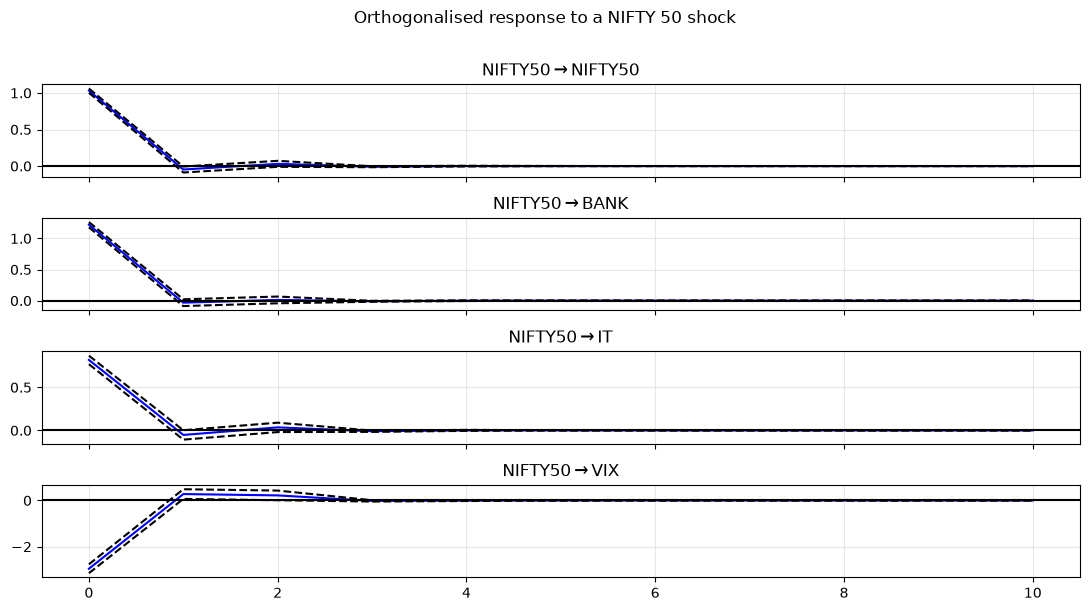

response to a one-s.d. NIFTY 50 shock (%), h = 0..4
   NIFTY50    BANK      IT     VIX
0   1.0313  1.2207  0.8185 -2.9557
1  -0.0469 -0.0325 -0.0523  0.2771
2   0.0308  0.0119  0.0355  0.2189
3  -0.0089 -0.0100 -0.0093 -0.0182
4  -0.0001 -0.0004  0.0007 -0.0060


In [6]:
irf = var_res.irf(10)
fig = irf.plot(orth=True, impulse="NIFTY50", figsize=(11, 6))
fig.suptitle("Orthogonalised response to a NIFTY 50 shock", y=1.01)
plt.tight_layout(); plt.show()

print("response to a one-s.d. NIFTY 50 shock (%), h = 0..4")
print(pd.DataFrame(irf.orth_irfs[:5, :, 0], columns=ret.columns).round(4).to_string())

The entire effect lands **on day 0** — a NIFTY 50 shock moves Bank +1.22%, IT +0.82% and VIX −2.96% contemporaneously, and everything is back to ≈ 0 by day 1. The information is absorbed immediately; there is no multi-day propagation.

### Forecast error variance decomposition

FEVD splits the $h$-step forecast error variance of each variable into the share attributable to each shock — "where does the uncertainty come from?" Same Cholesky ordering, same caveat.

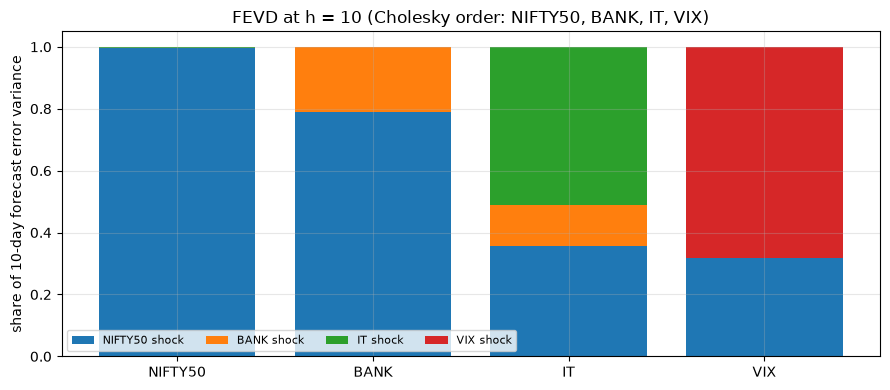

         NIFTY50   BANK     IT    VIX
NIFTY50    0.995  0.003  0.000  0.002
BANK       0.790  0.209  0.000  0.001
IT         0.355  0.133  0.509  0.002
VIX        0.316  0.001  0.001  0.682


In [7]:
fevd = var_res.fevd(10)
share = pd.DataFrame(fevd.decomp[:, 9, :], index=ret.columns, columns=ret.columns)

fig, ax = plt.subplots(figsize=(9, 4))
bottom = np.zeros(len(share))
for c in share.columns:
    ax.bar(share.index, share[c], bottom=bottom, label=f"{c} shock")
    bottom += share[c].values
ax.set_ylabel("share of 10-day forecast error variance")
ax.set_title("FEVD at h = 10 (Cholesky order: NIFTY50, BANK, IT, VIX)")
ax.legend(fontsize=8, ncol=4)
plt.tight_layout(); plt.show()

print(share.round(3).to_string())

NIFTY 50 is **99.5% self-explained** — nothing in this system helps predict it. Bank is 79% driven by NIFTY 50 shocks, IT is 51% its own, and VIX is 32% NIFTY 50.

Read this as a market-factor result, not a causal chain. NIFTY 50 sits first in the Cholesky ordering, so it absorbs the common market shock that genuinely hits all four at once. Put IT first and its share would rise sharply.

### Forecasting

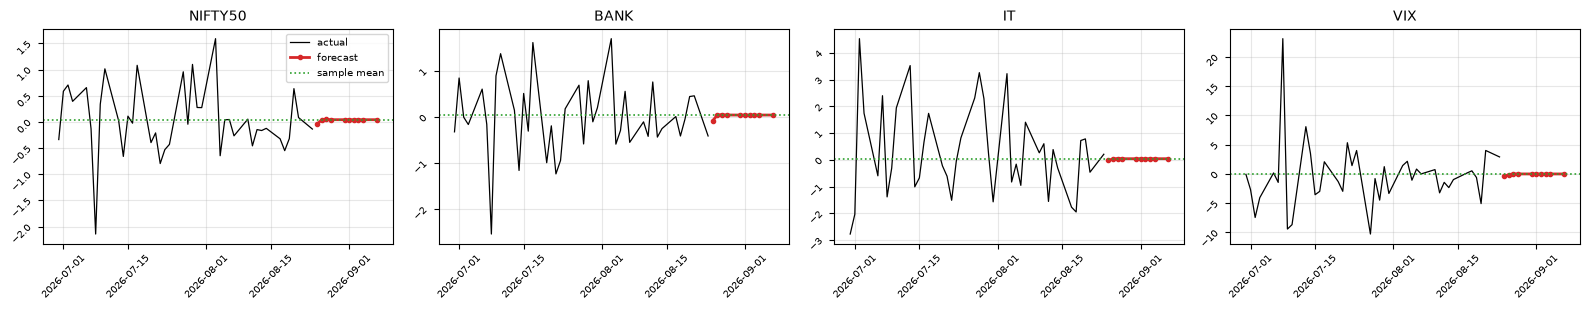

            NIFTY50    BANK      IT     VIX
2026-08-25  -0.0419 -0.0785 -0.0227 -0.3679
2026-08-26   0.0367  0.0453  0.0367 -0.1372
2026-08-27   0.0481  0.0538  0.0509  0.0049
2026-08-28   0.0429  0.0459  0.0444  0.0002
2026-08-31   0.0421  0.0446  0.0437 -0.0055

sample means: {'NIFTY50': 0.0424, 'BANK': 0.0446, 'IT': 0.0431, 'VIX': -0.0058}


In [8]:
h = 10
fc = pd.DataFrame(var_res.forecast(ret.values[-P:], h), columns=ret.columns,
                  index=pd.bdate_range(ret.index[-1] + pd.Timedelta(days=1), periods=h))

fig, axes = plt.subplots(1, 4, figsize=(16, 3.2))
for ax, c in zip(axes, ret.columns):
    ax.plot(ret[c].tail(40).index, ret[c].tail(40), lw=0.9, color="black", label="actual")
    ax.plot(fc.index, fc[c], lw=2, marker="o", ms=3, color="tab:red", label="forecast")
    ax.axhline(ret[c].mean(), color="tab:green", ls=":", lw=1.2, label="sample mean")
    ax.set_title(c, fontsize=10); ax.tick_params(labelrotation=45, labelsize=7)
axes[0].legend(fontsize=7)
plt.tight_layout(); plt.show()

print(fc.head(5).round(4).to_string())
print("\nsample means:", ret.mean().round(4).to_dict())

The forecasts collapse to the unconditional mean within about three days — the multivariate version of the AR mean-reversion from Module 5. For a stationary VAR, $\hat{\mathbf{y}}_{T+h} \to \boldsymbol{\mu}$ as $h$ grows, so a VAR on returns is a very short-horizon tool only.

## 2. VARMAX (optional)

VAR is to VARMA what AR is to ARMA — add a moving-average term, and optionally exogenous regressors:

$$\mathbf{y}_t = \mathbf{c} + \sum_{i=1}^{p}\Phi_i \mathbf{y}_{t-i} + \sum_{j=1}^{q}\Theta_j \boldsymbol{\varepsilon}_{t-j} + B\mathbf{x}_t + \boldsymbol{\varepsilon}_t$$

- **VMA terms** ($\Theta_j$) capture persistence that would otherwise need many VAR lags.
- **X** behaves exactly as in SARIMAX: exogenous, and its future values must be known.

**Why it is rarely used.** VARMA is not identified without extra restrictions — different $(\Phi, \Theta)$ pairs generate the same process — and estimation is slow and fragile. A slightly longer VAR is almost always preferred. Shown on two variables here because the cost grows quickly.

In [9]:
sub = ret[["NIFTY50", "VIX"]]

varmax = VARMAX(sub, order=(1, 1), trend="c").fit(disp=False, maxiter=60)   # slow: ~90s
var1   = VARMAX(sub, order=(1, 0), trend="c").fit(disp=False, maxiter=60)

print(f"VARMAX(1,1)  AIC {varmax.aic:9.1f}   params {len(varmax.params)}")
print(f"VAR(1)       AIC {var1.aic:9.1f}   params {len(var1.params)}")
print(f"\nAIC improvement from the MA term: {var1.aic - varmax.aic:.1f}")

VARMAX(1,1)  AIC   21274.5   params 13
VAR(1)       AIC   21293.7   params 9

AIC improvement from the MA term: 19.2


The MA term buys about 19 AIC points for 4 extra parameters and roughly 15× the fitting time. Real, but marginal — which is why VAR is the practical default.

## 3. Granger causality (high level)

**Definition.** $X$ *Granger-causes* $Y$ if past values of $X$ improve the prediction of $Y$ beyond what $Y$'s own past already provides. It is a statement about **predictive content**, nothing more.

Compare two regressions:

$$\text{restricted:}\quad y_t = c + \sum_{i=1}^{p}\alpha_i y_{t-i} + u_t
\qquad
\text{unrestricted:}\quad y_t = c + \sum_{i=1}^{p}\alpha_i y_{t-i} + \sum_{i=1}^{p}\beta_i x_{t-i} + e_t$$

and test $H_0: \beta_1 = \cdots = \beta_p = 0$ with an F-test. Rejecting means $X$ helps predict $Y$.

**What it is not.** The name oversells it:

- **Not causation.** A confounder driving both with different lags produces Granger causality with no causal link.
- **Prediction only.** It says $X$ carries information about $Y$'s future, not that intervening on $X$ would change $Y$.
- **Sensitive to $p$** and to the variable set — an omitted common driver can manufacture a result.
- **Requires stationarity**, which is why this runs on returns rather than levels.
- **Blind to contemporaneous effects.** If $X$ moves $Y$ within the same period, the test finds nothing.

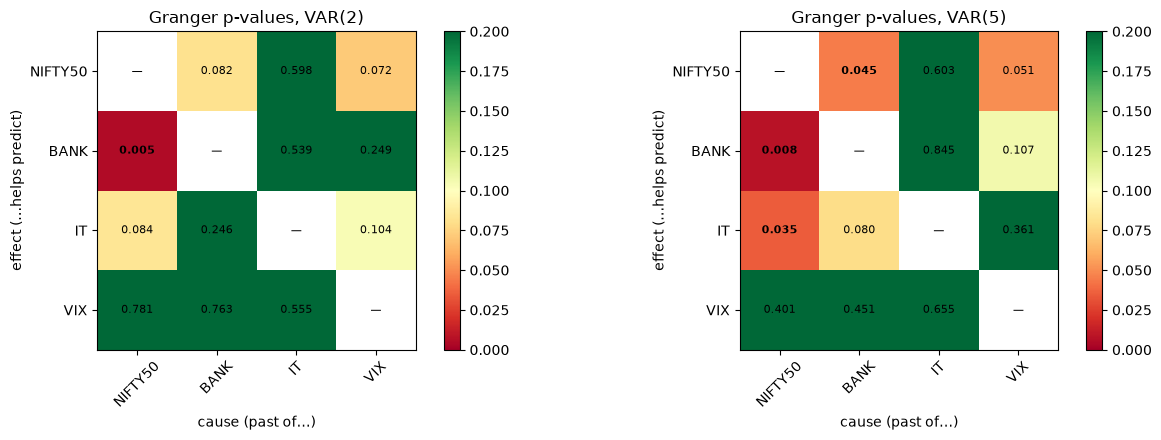

VAR(2) significant at 5%: NIFTY50→BANK (p=0.0051)
VAR(5) significant at 5%: BANK→NIFTY50 (p=0.0452), NIFTY50→BANK (p=0.0082), NIFTY50→IT (p=0.0348)


In [10]:
def granger_matrix(data, lag):
    '''p-value that the column variable Granger-causes the row variable.'''
    out = pd.DataFrame(np.nan, index=data.columns, columns=data.columns)
    res = VAR(data).fit(lag)
    for effect in data.columns:
        for cause in data.columns:
            if cause != effect:
                out.loc[effect, cause] = res.test_causality(effect, [cause], kind="f").pvalue
    return out

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, lag in zip(axes, (2, 5)):
    gm = granger_matrix(ret, lag)
    im = ax.imshow(gm.values, cmap="RdYlGn", vmin=0, vmax=0.2)
    ax.set_xticks(range(4), gm.columns, rotation=45)
    ax.set_yticks(range(4), gm.index)
    ax.set_xlabel("cause (past of…)"); ax.set_ylabel("effect (…helps predict)")
    ax.set_title(f"Granger p-values, VAR({lag})")
    ax.grid(False)
    for i in range(4):
        for j in range(4):
            v = gm.values[i, j]
            ax.text(j, i, "—" if np.isnan(v) else f"{v:.3f}", ha="center", va="center",
                    fontsize=8, fontweight="bold" if v < 0.05 else "normal")
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()

for lag in (2, 5):
    gm = granger_matrix(ret, lag)
    sig = [(c, e, gm.loc[e, c]) for e in gm.index for c in gm.columns
           if not np.isnan(gm.loc[e, c]) and gm.loc[e, c] < 0.05]
    print(f"VAR({lag}) significant at 5%: " +
          (", ".join(f"{c}→{e} (p={p:.4f})" for c, e, p in sig) if sig else "none"))

**Results, and the caveats they make concrete:**

- At **p = 2** only **NIFTY 50 → Bank** is significant (p = 0.005). At **p = 5** three links appear, including **Bank → NIFTY 50** — so the two now "cause" each other. Lag-sensitivity is not a footnote: report the lag order, or the result means little.
- **NIFTY 50 and Bank correlate 0.89 contemporaneously, yet Granger causality is marginal.** Correlation is same-day co-movement; Granger causality is lead-lag. Different questions, and here the strong answer belongs to the first.
- **VIX Granger-causes nothing in either direction** (all p > 0.05) despite correlating −0.55 with NIFTY 50. The leverage effect is contemporaneous, and the test is blind to same-period relationships by construction.
- 12 tests at the 5% level implies ~0.6 false positives by chance alone. The p = 5 findings at 0.035 and 0.045 sit exactly where multiple testing bites — apply a correction before believing them.

The overall reading is the honest one for daily index data: **no exploitable lead-lag structure**, which is what BIC already said when it chose lag 0.